In [1]:
import os, pickle, glob
from pyspark.sql import SparkSession
from pyspark.ml.feature import Word2Vec
from pyspark.sql.functions import col, count, when, length
import matplotlib.pyplot as plt

Matplotlib created a temporary cache directory at /scratch/mnodini/job_48542147/matplotlib-4b2vjs9v because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# Spark Session Builder

spark = SparkSession.builder \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "10g") \
    .config('spark.executor.instances', 15) \
    .getOrCreate()

In [3]:
spark

In [4]:
import requests
import pandas as pd

# Get the active Spark Context and URL
sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"

# Fetch the executor data from the API
response = requests.get(url)
executors = response.json()

# Format into a readable DataFrame
df = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
df['maxMemory_GB'] = (df['maxMemory'] / (1024**3)).round(2)
df

,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,16,1099746508,0,True,1.02


In [5]:
# # load all csv files from shared folder into one df
# df = spark.read.csv("../gkao/shared/", header=True, inferSchema=True)

In [6]:
# gkao/shared/
# load all csv files from shared folder into one df
df = spark.read.csv("../gkao/shared/outputRS_2021-07.csv", header=True, inferSchema=True)

In [7]:
# store dataframe in memory for faster reuse
# df.cache()

In [8]:
# check how many rows and columns we have
print("Rows:", df.count())
print("Columns:", len(df.columns))

Rows: 28923271
Columns: 6


# Plot Under 18

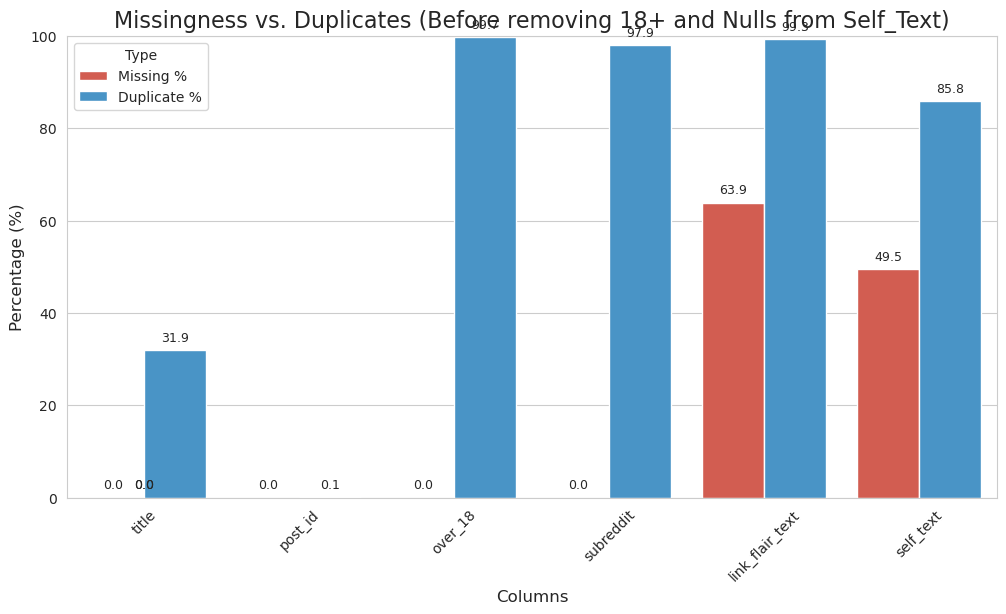

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql import functions as F

# 1. Calculate the metrics in Spark
total_rows = df.count()

stats_exprs = []
for c in df.columns:
    # Missingness
    stats_exprs.append(
        (F.count(F.when(F.col(c).isNull() | F.isnan(F.col(c)), c)) / total_rows * 100).alias(f"{c}_missing")
    )
    # Column-level duplicates
    stats_exprs.append(
        ((total_rows - F.countDistinct(c)) / total_rows * 100).alias(f"{c}_duplicate")
    )

# 2. Collect to Pandas
# This is efficient because the result is just 1 row with 2x columns
summary_dict = df.select(stats_exprs).first().asDict()

# 3. Reshape the data for plotting
plot_data = []
for col in df.columns:
    plot_data.append({'Column': col, 'Type': 'Missing %', 'Value': summary_dict[f"{col}_missing"]})
    plot_data.append({'Column': col, 'Type': 'Duplicate %', 'Value': summary_dict[f"{col}_duplicate"]})

pdf = pd.DataFrame(plot_data)

# 4. Create the Bar Graph
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(x='Column', y='Value', hue='Type', data=pdf, palette=['#e74c3c', '#3498db'])

# Formatting the chart
plt.title('Missingness vs. Duplicates (Before removing 18+ and Nulls from Self_Text)', fontsize=16)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Columns', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 100) # Ensure scale is 0-100%

# Add text labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=9)

# plt.tight_layout()
plt.show()

# Remove Over_18 & Where self_text is Null

In [10]:
from pyspark.sql.functions import col
df = df.where("over_18 = false")
df_cleaned = df.filter(col("self_text").isNotNull())
df = df_cleaned

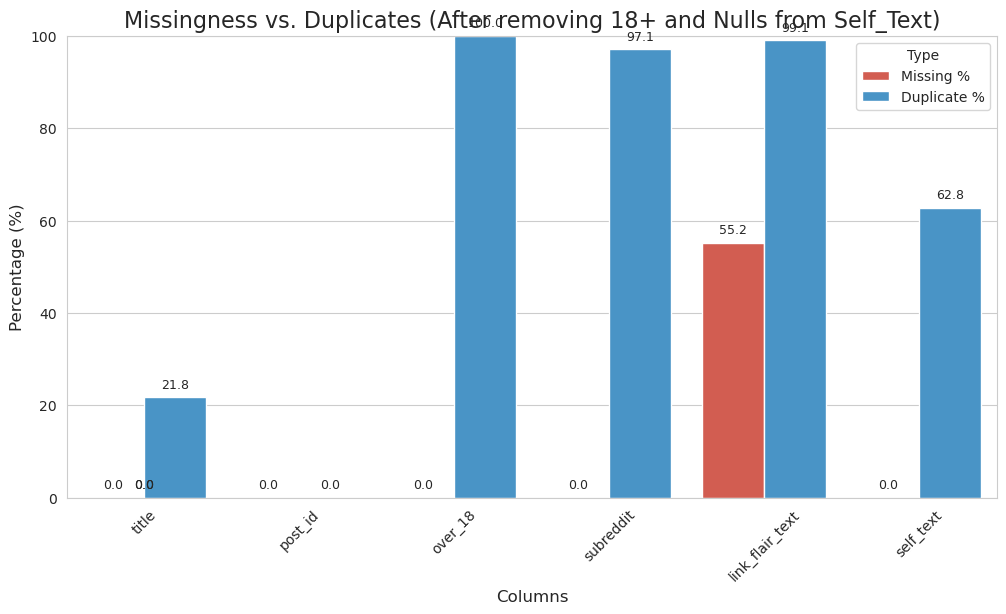

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql import functions as F

# 1. Calculate the metrics in Spark
total_rows = df.count()

stats_exprs = []
for c in df.columns:
    # Missingness
    stats_exprs.append(
        (F.count(F.when(F.col(c).isNull() | F.isnan(F.col(c)), c)) / total_rows * 100).alias(f"{c}_missing")
    )
    # Column-level duplicates
    stats_exprs.append(
        ((total_rows - F.countDistinct(c)) / total_rows * 100).alias(f"{c}_duplicate")
    )

# 2. Collect to Pandas
# This is efficient because the result is just 1 row with 2x columns
summary_dict = df.select(stats_exprs).first().asDict()

# 3. Reshape the data for plotting
plot_data = []
for col in df.columns:
    plot_data.append({'Column': col, 'Type': 'Missing %', 'Value': summary_dict[f"{col}_missing"]})
    plot_data.append({'Column': col, 'Type': 'Duplicate %', 'Value': summary_dict[f"{col}_duplicate"]})

pdf = pd.DataFrame(plot_data)

# 4. Create the Bar Graph
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(x='Column', y='Value', hue='Type', data=pdf, palette=['#e74c3c', '#3498db'])

# Formatting the chart
plt.title('Missingness vs. Duplicates (After removing 18+ and Nulls from Self_Text)', fontsize=16)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Columns', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 100) # Ensure scale is 0-100%

# Add text labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=9)

# plt.tight_layout()
plt.show()

# Percentage of Data in each subreddit (Non 18+ & Self_Text Not Null)

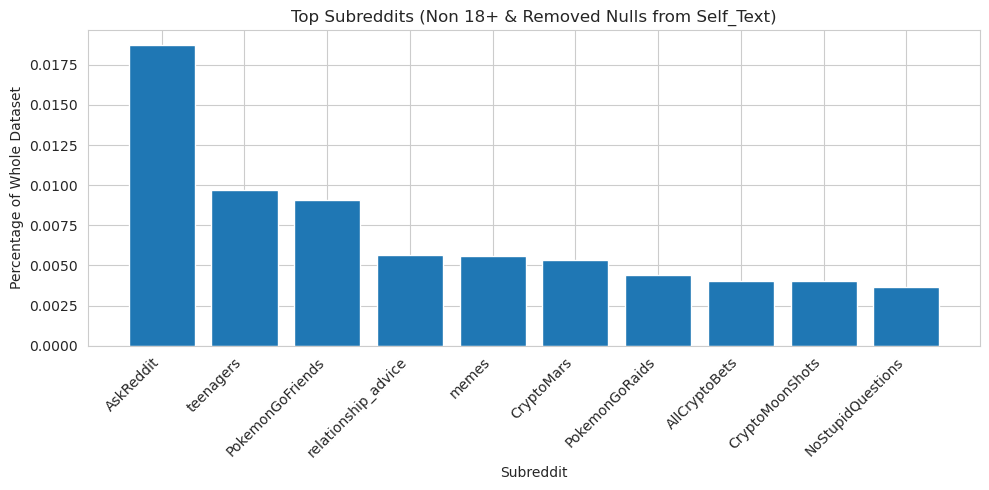

In [12]:
from pyspark.sql.functions import col
# get top 10 subreddits
top_subreddits = df.groupBy("subreddit") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(10)

# convert to pandas for plotting
top_subreddits_pd = top_subreddits.toPandas()
top_subreddits_pd['count'] = top_subreddits_pd['count'] / df.count()

# plot bar chart
plt.figure(figsize=(10, 5))
plt.bar(top_subreddits_pd["subreddit"], top_subreddits_pd["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top Subreddits (Non 18+ & Removed Nulls from Self_Text)")
plt.xlabel("Subreddit")
plt.ylabel("Percentage of Whole Dataset")
plt.tight_layout()
plt.show()

In [ ]:
# print column names
print(df.columns)

In [ ]:
# see data types for each column
df.printSchema()

In [ ]:
# preview first few rows
df.show(5, truncate=False)

In [ ]:
# count null or empty values
empty_or_null_df = df.select([
    count(when(col(c).isNull() | (col(c) == ""), 1)).alias(c)
    for c in df.columns
])

empty_or_null_df.show()

In [ ]:
# check duplicate post IDs 
total_rows = df.count()

unique_post_ids = df.select("post_id").dropDuplicates().count()

print("Total rows:", total_rows)
print("Duplicate post_ids:", total_rows - unique_post_ids)

In [ ]:
# see number of unique subreddits
df.select("subreddit").distinct().count()

In [ ]:
# top subreddits by number of posts
df.groupBy("subreddit") \
  .count() \
  .orderBy(col("count").desc()) \
  .show(20, truncate=False)

In [ ]:
# look at distribution of title lengths
df.select(length(col("title")).alias("title_length")).describe().show()

In [ ]:
# get top 10 subreddits
top_subreddits = df.groupBy("subreddit") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(10)

# convert to pandas for plotting
top_subreddits_pd = top_subreddits.toPandas()

# plot bar chart
plt.figure(figsize=(10, 5))
plt.bar(top_subreddits_pd["subreddit"], top_subreddits_pd["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top Subreddits")
plt.xlabel("Subreddit")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# count over_18 values
over18_counts = df.groupBy("over_18").count()

over18_pd = over18_counts.toPandas()

over18_pd["over_18"] = over18_pd["over_18"].astype(str).str.replace(r"[\$\[\]]", "", regex=True)

# plot
plt.figure(figsize=(6, 4))
plt.bar(over18_pd["over_18"], over18_pd["count"])
plt.title("over_18 Distribution")
plt.xlabel("over_18")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# count over_18 values
over18_counts = df.groupBy("over_18").count()

over18_pd = over18_counts.toPandas()

# bar chart
plt.figure(figsize=(6, 4))
plt.bar(over18_pd["over_18"].astype(str), over18_pd["count"])
plt.title("over_18 Distribution")
plt.xlabel("over_18")
plt.ylabel("Count")
plt.tight_layout()
plt.show()